Install and import the packages

In [12]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import gseapy as gp

Load Significant Genes and Define Gene Lists

In [13]:
# Load the limma result with gene symbols
res = pd.read_csv("/workspaces/Malaria-host-response-systems/data/processed/limma_voom_symptomatic_vs_asymptomatic_with_symbols.csv")

# Filter for significant genes (per-contrast BH adj.P.Val < 0.15)
sig = res[(res['adj.P.Val'] < 0.15) & res['Symbol'].notna()]

# Up in symptomatic (positive logFC), down in asymptomatic
up_genes = sig[sig['logFC'] > 0]['Symbol'].tolist()
down_genes = sig[sig['logFC'] < 0]['Symbol'].tolist()

print(f"Total significant genes: {len(sig)}")
print(f"Up in symptomatic: {len(up_genes)}")
print(f"Down in symptomatic: {len(down_genes)}")

Total significant genes: 280
Up in symptomatic: 200
Down in symptomatic: 80


Run Enrichment and Add Gene Memberships

In [15]:
import gseapy as gp

# Define libraries to use
libraries = ['GO_Biological_Process_2023', 'KEGG_2021_Human', 'Reactome_2022']

# Function to run enrichment and then add gene memberships from the library
def run_enrichment_with_genes(gene_list, library_name, cutoff=0.1):
    # Run enrichr
    enr = gp.enrichr(gene_list=gene_list,
                     gene_sets=library_name,
                     organism='human',
                     outdir=None,
                     cutoff=cutoff)
    results = enr.results
    
    # Download the full library gene sets
    full_lib = gp.get_library(name=library_name, organism='human')
    
    # Add a 'Genes' column to results (join with semicolons)
    results['Genes'] = results['Term'].map(lambda term: ';'.join(full_lib.get(term, [])))
    return results

# Run for up and down genes
enr_up_detail = {}
enr_down_detail = {}

for lib in libraries:
    print(f"Processing {lib} for up genes...")
    enr_up_detail[lib] = run_enrichment_with_genes(up_genes, lib)
    print(f"Processing {lib} for down genes...")
    enr_down_detail[lib] = run_enrichment_with_genes(down_genes, lib)

print("Detailed enrichment with gene memberships completed.")

Processing GO_Biological_Process_2023 for up genes...


Processing GO_Biological_Process_2023 for down genes...
Processing KEGG_2021_Human for up genes...
Processing KEGG_2021_Human for down genes...
Processing Reactome_2022 for up genes...
Processing Reactome_2022 for down genes...
Detailed enrichment with gene memberships completed.


Build the Gene–Pathway Network

In [16]:
# Create an empty graph
G = nx.Graph()

# Helper function to add edges from enrichment results
def add_edges_from_enrichment(G, enr_df, gene_list, gene_type):
    for _, row in enr_df.iterrows():
        pathway = row['Term']
        genes_in_term = row['Genes'].split(';')  # genes separated by semicolons
        for gene in genes_in_term:
            if gene in gene_list:
                G.add_node(gene, node_type='gene', direction=gene_type)
                G.add_node(pathway, node_type='pathway')
                G.add_edge(gene, pathway)

# Add up-regulated genes (symptomatic)
for lib, df in enr_up_detail.items():
    add_edges_from_enrichment(G, df, up_genes, gene_type='up')

# Add down-regulated genes (asymptomatic)
for lib, df in enr_down_detail.items():
    add_edges_from_enrichment(G, df, down_genes, gene_type='down')

print(f"Network has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Network has 3103 nodes and 7680 edges.


Compute Degree for Gene Nodes

In [17]:
# Get all gene nodes
gene_nodes = [n for n, attr in G.nodes(data=True) if attr.get('node_type') == 'gene']

# Compute degree for each gene
degree_dict = dict(G.degree(gene_nodes))
degree_df = pd.DataFrame.from_dict(degree_dict, orient='index', columns=['degree'])
degree_df = degree_df.sort_values('degree', ascending=False)

# Add logFC information
gene_logfc = sig.set_index('Symbol')['logFC'].to_dict()
degree_df['logFC'] = degree_df.index.map(gene_logfc)

print("Top 20 gene hubs by degree:")
print(degree_df.head(20))

Top 20 gene hubs by degree:
        degree     logFC
SIRT1      253 -0.605431
CAV1       208  1.693834
PSMD14     169  0.522949
PSMC2      162  0.552082
EGF        158  3.632331
PSMA5      156  0.528895
CLU        133  2.974810
E2F1       116  1.982115
H2BC11     115  2.483182
ITGB3      108  2.577326
H2BC12     106  1.313271
H2BC15     102  1.925157
SMAD7      102 -1.117654
CASP3      101  0.487855
H2BC5       98  1.430589
PCNA        92  1.172669
LILRB1      92  0.952403
H2AC6       92  2.123787
ADCY9       91 -0.621414
YWHAE       91  0.751538


Visualize Top Hubs and Their Pathways

/tmp/ipykernel_57737/1131792614.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


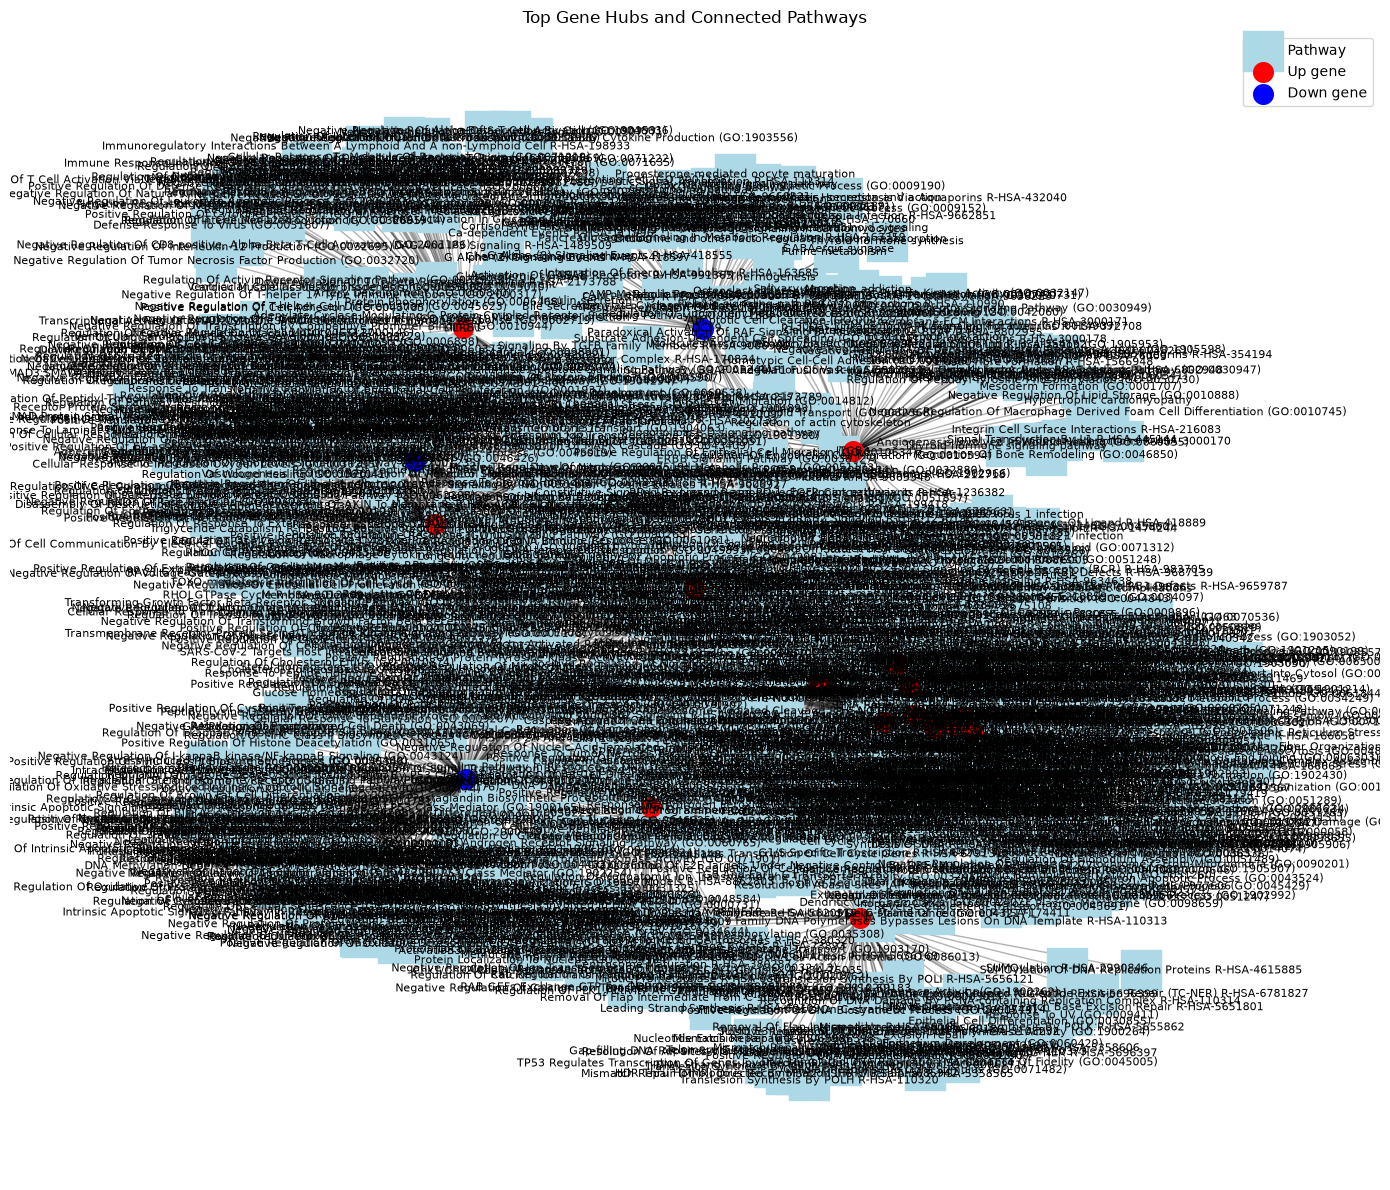

In [18]:
# Select top 20 hubs
top_hubs = degree_df.head(20).index.tolist()

# Get pathways connected to these hubs
pathways_connected = set()
for hub in top_hubs:
    pathways_connected.update(list(G.neighbors(hub)))

# Create subgraph with top hubs and their pathways
subgraph_nodes = set(top_hubs) | pathways_connected
subG = G.subgraph(subgraph_nodes)

# Position layout
pos = nx.spring_layout(subG, k=0.5, seed=42)

plt.figure(figsize=(14, 12))

# Draw pathway nodes as squares, gene nodes as circles colored by direction
pathway_nodes = [n for n, attr in subG.nodes(data=True) if attr.get('node_type') == 'pathway']
gene_nodes_up = [n for n, attr in subG.nodes(data=True) if attr.get('node_type') == 'gene' and attr.get('direction') == 'up']
gene_nodes_down = [n for n, attr in subG.nodes(data=True) if attr.get('node_type') == 'gene' and attr.get('direction') == 'down']

nx.draw_networkx_nodes(subG, pos, nodelist=pathway_nodes, node_shape='s', node_color='lightblue', node_size=800, label='Pathway')
nx.draw_networkx_nodes(subG, pos, nodelist=gene_nodes_up, node_color='red', node_size=200, label='Up gene')
nx.draw_networkx_nodes(subG, pos, nodelist=gene_nodes_down, node_color='blue', node_size=200, label='Down gene')
nx.draw_networkx_edges(subG, pos, alpha=0.3)
nx.draw_networkx_labels(subG, pos, font_size=8)

plt.legend(scatterpoints=1)
plt.title('Top Gene Hubs and Connected Pathways')
plt.axis('off')
plt.tight_layout()
plt.savefig('/workspaces/Malaria-host-response-systems/results/figures/network_top_hubs.png', dpi=150, bbox_inches='tight')
plt.show()

Pyvis

In [19]:
# Install pyvis if not already
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 8.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pyvis]32m1/2 [pyvis]
/workspaces/Malaria-host-response-systems/results/figures/network_top_hubs_interactive.html


In [21]:
print(degree_df.head(20).to_string())

        degree     logFC
SIRT1      253 -0.605431
CAV1       208  1.693834
PSMD14     169  0.522949
PSMC2      162  0.552082
EGF        158  3.632331
PSMA5      156  0.528895
CLU        133  2.974810
E2F1       116  1.982115
H2BC11     115  2.483182
ITGB3      108  2.577326
H2BC12     106  1.313271
H2BC15     102  1.925157
SMAD7      102 -1.117654
CASP3      101  0.487855
H2BC5       98  1.430589
PCNA        92  1.172669
LILRB1      92  0.952403
H2AC6       92  2.123787
ADCY9       91 -0.621414
YWHAE       91  0.751538
